In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
S = ['High', 'Low', 'Charging'] #States [High -> 0 | Low -> 1 | Charging -> 2]
A = ['Search', 'Wait']#Action [Search -> 0 | Wait -> 1]

n_s = len(S) #number of states
n_a = len(A) #number of actions

In [3]:
P = np.zeros((n_s, n_a, n_s)) #Transition Matrix 3D (3 x 2 x 3)
R = np.zeros((n_s, n_a)) #Reward Matrix 2D (3 x 2)

In [4]:
P[0, 0, 0] = 0.7 # High -> Search -> High
P[0, 0, 1] = 0.3 # High -> Search -> Low

P[0, 1, 0] = 1.0 # High -> Wait -> High

P[1, 0, 0] = 0.4 # Low -> Search -> High
P[1, 0, 1] = 0.6 # Low -> Search -> Low

P[1, 1, 1] = 1.0 # Low -> Wait -> Low

P[2, 1, 0] = 1.0 # Charging -> Wait -> High

In [5]:
R[0, 0] = 4 # High and Search
R[0, 1] = 1 # High and Wait

R[1, 0] = -3 # Low and Search
R[1, 1] = 1 # Low and Wait

R[2, 1] = 0 # Charging and Wait

**Checking Transition Probabilities**

In [6]:
for s in range(n_s):
    for a in range(n_a):
        print(f"P[{S[s]}, {A[a]}] sum = {P[s, a, :].sum()}")

print("\nReward Matrix R : " )
print(R)

P[High, Search] sum = 1.0
P[High, Wait] sum = 1.0
P[Low, Search] sum = 1.0
P[Low, Wait] sum = 1.0
P[Charging, Search] sum = 0.0
P[Charging, Wait] sum = 1.0

Reward Matrix R : 
[[ 4.  1.]
 [-3.  1.]
 [ 0.  0.]]


In [7]:
policy = np.array((0, 1, 1)) # 0 -> Search | 1 -> Wait.

**Policy Evaluation Function**

In [8]:
def policy_evaluation(P, R, policy, g = 0.9, t = 1e-6):
    n_s = P.shape[0]
    V = np.zeros(n_s)

    iter = 0

    while True:
        delta = 0
        new_V = np.zeros(n_s)

        for s in range(n_s):
            a = policy[s]
            value = 0

            for s_next in range(n_s):
                prob = P[s, a, s_next]
                value += prob * (R[s, a] + g*V[s_next])
            
            new_V[s] = value

            delta = max(delta, abs(new_V[s] - V[s]))
            
        V = new_V
        iter += 1

        if delta < t:
            break

    print(f"\nConverged in {iter} iterations")
    return V

**Evaluation**

In [9]:
g = 0.9
t = 1e-6

V = policy_evaluation(P, R, policy, g, t)

print("\nFinal Value Function :")
for i in range(n_s):
    print(f"V({S[i]}) = {V[i]:.4f}")


Converged in 133 iterations

Final Value Function :
V(High) = 18.1081
V(Low) = 10.0000
V(Charging) = 16.2973


**Plot Bar Chart**

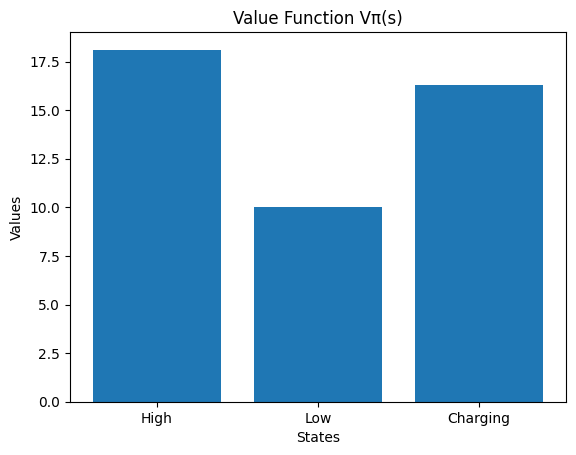

In [16]:
plt.bar(S, V)
plt.title("Value Function Vπ(s)")
plt.xlabel("States")
plt.ylabel("Values")
plt.show()